#Prompt 1 – Load the Dataset

#Write Python code to load the Network Traffic dataset using Pandas and display the first five records.


In [2]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print(df.head())

    Duration Protocol       SourceIP  DestinationIP  SourcePort  \
0  24.077749      TCP  192.168.1.239  192.168.1.234        8055   
1  97.252384     ICMP  192.168.1.176   192.168.1.82       63174   
2  85.842654      TCP  192.168.1.120  192.168.1.113       30873   
3  79.196991      UDP  192.168.1.212  192.168.1.140        4410   
4  34.928018      TCP   192.168.1.17  192.168.1.223        4702   

   DestinationPort  PacketCount  ByteCount   Label  
0                1          827     198244  Attack  
1              687          673    1202973  Normal  
2              570          319     984671  Attack  
3              683          375      36284  Normal  
4              989          465     817463  Normal  


#Prompt 2 – Display Dataset Information

#Write Python code to display the structure and data types of the dataset.

In [3]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Duration         2000 non-null   float64
 1   Protocol         2000 non-null   object 
 2   SourceIP         2000 non-null   object 
 3   DestinationIP    2000 non-null   object 
 4   SourcePort       2000 non-null   int64  
 5   DestinationPort  2000 non-null   int64  
 6   PacketCount      2000 non-null   int64  
 7   ByteCount        2000 non-null   int64  
 8   Label            2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


#Prompt 3 – Check Missing Values

#Write Python code to identify missing values in the dataset.

In [4]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print(df.isnull().sum())

Duration           0
Protocol           0
SourceIP           0
DestinationIP      0
SourcePort         0
DestinationPort    0
PacketCount        0
ByteCount          0
Label              0
dtype: int64


#Prompt 4 – Count Normal and Attack Records

#Write Python code to count the number of Normal and Attack records.

In [5]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print(df["Label"].value_counts())

Label
Attack    1022
Normal     978
Name: count, dtype: int64


#Prompt 5 – Calculate Average Duration

#Write Python code to calculate the average network session duration.

In [6]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print("Average Duration:", df["Duration"].mean())

Average Duration: 50.29468947738316


#Prompt 6 – Find Maximum Packet Count

#Write Python code to find the maximum packet count recorded in the dataset.

In [7]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

print("Maximum Packet Count:", df["PacketCount"].max())

Maximum Packet Count: 999


#Prompt 7 – Display Only Attack Records

#Write Python code to display only the records labeled as Attack.

In [8]:
import pandas as pd

df = pd.read_csv("network_traffic_data.csv")

attacks = df[df["Label"] == "Attack"]

print(attacks.head())

    Duration Protocol       SourceIP  DestinationIP  SourcePort  \
0  24.077749      TCP  192.168.1.239  192.168.1.234        8055   
2  85.842654      TCP  192.168.1.120  192.168.1.113       30873   
5  31.135166      TCP  192.168.1.141  192.168.1.233       49643   
6  22.896530      TCP   192.168.1.86  192.168.1.219       52005   
8  65.646803      TCP  192.168.1.235   192.168.1.62        4393   

   DestinationPort  PacketCount  ByteCount   Label  
0                1          827     198244  Attack  
2              570          319     984671  Attack  
5              328          766      47409  Attack  
6              571          361     526498  Attack  
8              767          105     186558  Attack  


#Prompt 8 – Detect Anomalies Using Isolation Forest

#Write Python code to apply the Isolation Forest algorithm to detect anomalous network traffic based on Duration, PacketCount, and ByteCount.

In [9]:
import pandas as pd
from sklearn.ensemble import IsolationForest

df = pd.read_csv("network_traffic_data.csv")

X = df[["Duration", "PacketCount", "ByteCount"]]

model = IsolationForest(contamination=0.05, random_state=42)

df["Prediction"] = model.fit_predict(X)

print(df[["Duration", "PacketCount", "ByteCount", "Prediction"]].head())

    Duration  PacketCount  ByteCount  Prediction
0  24.077749          827     198244           1
1  97.252384          673    1202973           1
2  85.842654          319     984671           1
3  79.196991          375      36284           1
4  34.928018          465     817463           1


#Prompt 9 – Visualize Packet Count Distribution (Matplotlib)

#Write Python code to visualize the distribution of Packet Count using a histogram.

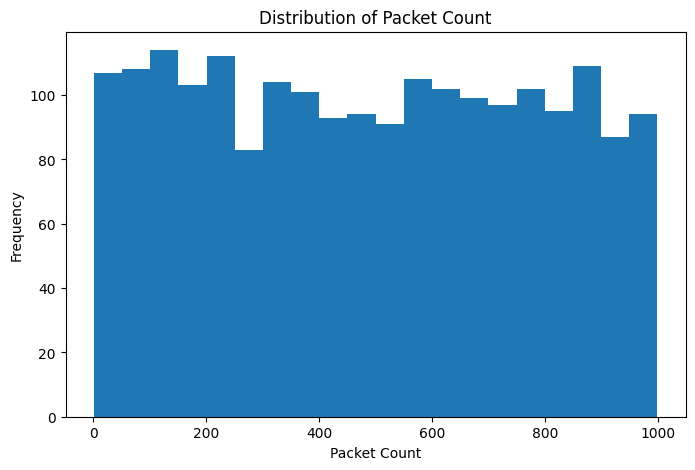

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("network_traffic_data.csv")

plt.figure(figsize=(8,5))
plt.hist(df["PacketCount"], bins=20)

plt.title("Distribution of Packet Count")
plt.xlabel("Packet Count")
plt.ylabel("Frequency")

plt.show()

#Prompt 10 – Visualize Isolation Forest Results (Matplotlib)

#Write Python code to visualize anomalies detected by the Isolation Forest algorithm using a scatter plot.

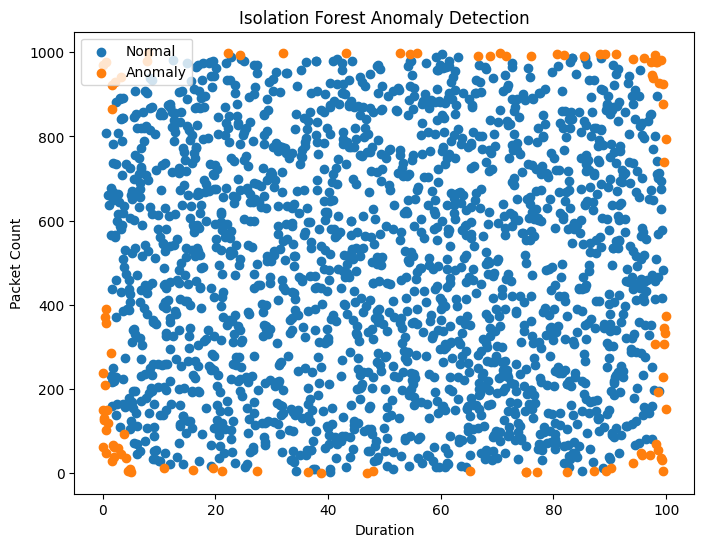

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("network_traffic_data.csv")

X = df[["Duration", "PacketCount"]]

model = IsolationForest(contamination=0.05, random_state=42)

df["Prediction"] = model.fit_predict(X)

normal = df[df["Prediction"] == 1]
anomaly = df[df["Prediction"] == -1]

plt.figure(figsize=(8,6))

plt.scatter(normal["Duration"], normal["PacketCount"], label="Normal")
plt.scatter(anomaly["Duration"], anomaly["PacketCount"], label="Anomaly")

plt.xlabel("Duration")
plt.ylabel("Packet Count")
plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.show()